MODEL:resnet18_MNIST_1 , Train Loss: 0.0037, Train Accuracy: 95.80, Validation Loss: 0.1050, Validation Accuracy: 96.84%
MODEL:resnet18-MNIST-random-0.3-1 , Train Loss: 0.0096, Train Accuracy: 94.73, Validation Loss: 0.1034, Validation Accuracy: 96.75%
MODEL:resnet18-MNIST-random-0.5-1 , Train Loss: 0.0160, Train Accuracy: 93.96, Validation Loss: 0.1025, Validation Accuracy: 96.60%
MODEL:resnet18-MNIST-random-0.7-1 , Train Loss: 0.0384, Train Accuracy: 92.67, Validation Loss: 0.1837, Validation Accuracy: 94.25%
MODEL:resnet18-MNIST-random-0.8-1 , Train Loss: 0.0891, Train Accuracy: 90.75, Validation Loss: 0.1523, Validation Accuracy: 94.98%
MODEL:resnet18-MNIST-random-0.9-1 , Train Loss: 0.3440, Train Accuracy: 87.48, Validation Loss: 0.2905, Validation Accuracy: 91.51%
MODEL:resnet18-MNIST-random-0.95-1 , Train Loss: 0.4817, Train Accuracy: 82.00, Validation Loss: 0.9064, Validation Accuracy: 75.64%
MODEL:resnet18-MNIST-predictive_entropy-balanced_by_score-0.3-1 , Train Loss: 0.0077, 

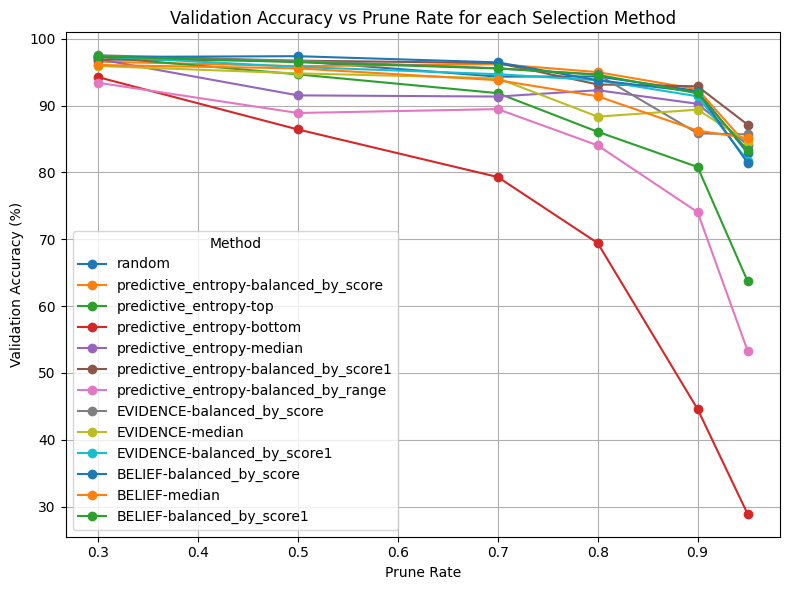

,Method,Prune Rate,Avg. Validation Accuracy (%)
0,random,0.30,97.28
1,random,0.50,96.62
2,random,0.70,94.32
3,random,0.80,94.35
4,random,0.90,92.18
...,...,...,...
73,BELIEF-balanced_by_score1,0.50,96.48
74,BELIEF-balanced_by_score1,0.70,95.54
75,BELIEF-balanced_by_score1,0.80,94.61
76,BELIEF-balanced_by_score1,0.90,91.82


In [11]:
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import pandas as pd
# Sample experiment log lines as a multi-line string
with open("models/modelStats.txt", "r") as file:
    log_data = file.read()
print(log_data)
# Regular expression patterns.
# This pattern expects lines like: "MODEL:resnet18-CIFAR10-random-0.3-1 ..."
# It captures: method, prune rate and repetition.
pattern = re.compile(
    r'MODEL:resnet18(?:[-_]EvidenceLoss)?[-_](?:CIFAR10|MNIST)[-_](.+?)(?=-([\d.]+)-(\d+))'
)
# Pattern to extract validation accuracy
val_acc_pattern = re.compile(r"Validation Accuracy:\s*([\d.]+)%")

# Dictionary to store results: { method: { prune_rate: [val_acc, ...], ... }, ... }
results = defaultdict(lambda: defaultdict(list))

# Process each line
for line in log_data.splitlines():
    # Skip empty lines
    if not line.strip():
        continue
    # If it doesn't match our expected pattern, skip it
    match = pattern.search(line)
    if not match:
        continue
    method, prune_rate_str, repetition = match.groups()
    prune_rate = float(prune_rate_str)
    
    # Extract the Validation Accuracy value.
    acc_match = val_acc_pattern.search(line)
    if acc_match:
        val_acc = float(acc_match.group(1))
    else:
        continue  # skip if validation accuracy is not found
    
    # Store the value
    results[method][prune_rate].append(val_acc)

# Average the validation accuracy for each method-prune rate grouping.
avg_results = {}
for method, pr_data in results.items():
    print(method)
    avg_results[method] = {}
    for p_rate, accs in pr_data.items():
        avg_results[method][p_rate] = np.mean(accs)

# Plotting
plt.figure(figsize=(8, 6))

for method, pr_data in avg_results.items():
    # Get sorted lists for x and y
    sorted_items = sorted(pr_data.items())
    x_vals = [item[0] for item in sorted_items]
    y_vals = [item[1] for item in sorted_items]
    plt.plot(x_vals, y_vals, marker='o', label=method)

plt.xlabel("Prune Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy vs Prune Rate for each Selection Method")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.show()
table_data = []
for method, pr_data in avg_results.items():
    for prune_rate, acc in pr_data.items():
        table_data.append({
            'Method': method,
            'Prune Rate': prune_rate,
            'Avg. Validation Accuracy (%)': round(acc, 2)
        })

df = pd.DataFrame(table_data)
display(df)